# MBQC Single-Qubit Gate RCS Notebook

Uses `TetronSingleQubitGates` from `src/tetron/single_qubit_gate.py`.

## Goals

**Part 1 — Verification.**  
For each of `√X`, `√Y`, `√W`: build the measurement-based circuit and the equivalent direct-Qiskit circuit side by side.  
Draw both circuits, run from |0⟩ and compare output distributions.

**Part 2 — 12-pair random single-qubit RCS.**  
Layout: 24 qubits — qubit `2i` is data qubit `i`, qubit `2i+1` is its ancilla.  
Each ancilla is initialised to |+⟩. Each data qubit gets a uniformly random gate from {`√X`, `√Y`, `√W`}.  
Run both the MBQC and direct circuits, draw both, and compare per-qubit output distributions.

---
**Qiskit direct equivalents used:**
| Gate | Direct Qiskit | Reason |
|------|--------------|--------|
| √X  | `qc.sx(q)` | HSH = SX (Qiskit native) |
| √Y  | `qc.s(q); qc.s(q); qc.h(q)` | HSS = H·Z |
| √W  | `qc.tdg(q); qc.sx(q); qc.t(q)` | T·√X·T† |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile

from single_qubit_gate import TetronSingleQubitGates

---
## Part 1 — Verification: √X, √Y, √W

In [2]:
BITS_PER = {'sqrt_X': 4, 'sqrt_Y': 9, 'sqrt_W': 4}

GATE_FNS = {
    'sqrt_X': TetronSingleQubitGates.gate_sqrt_X,
    'sqrt_Y': TetronSingleQubitGates.gate_sqrt_Y,
    'sqrt_W': TetronSingleQubitGates.gate_sqrt_W,
}

LABELS = {'sqrt_X': '\u221aX', 'sqrt_Y': '\u221aY', 'sqrt_W': '\u221aW'}


def apply_direct_gate(qc, gate_name, qubit):
    """Qiskit-native equivalent of each MBQC gate."""
    if gate_name == 'sqrt_X':
        qc.sx(qubit)
    elif gate_name == 'sqrt_Y':
        qc.s(qubit)
        qc.s(qubit)
        qc.h(qubit)
    elif gate_name == 'sqrt_W':
        qc.tdg(qubit)
        qc.sx(qubit)
        qc.t(qubit)


def build_mbqc_circuit(gate_name, init_state='0', n_reps=1):
    """
    2-qubit MBQC circuit: q[0]=ancilla (|+>), q[1]=data.
    c_int = intermediate measurement bits.
    c_out = final data-qubit measurement (1 bit).
    get_counts() bitstring format: 'c_out c_int' (space-separated, c_out leftmost).
    """
    n_int = BITS_PER[gate_name] * n_reps
    q     = QuantumRegister(2, 'q')
    c_int = ClassicalRegister(n_int, 'c_int')
    c_out = ClassicalRegister(1, 'c_out')
    qc    = QuantumCircuit(q, c_int, c_out)

    # Data qubit initial state
    if init_state == '1':
        qc.x(q[1])
    elif init_state == '+':
        qc.h(q[1])

    qc.h(q[0])

    for rep in range(n_reps):
        GATE_FNS[gate_name](qc, q[0], q[1], c_int,
                            start_idx=rep * BITS_PER[gate_name])
    qc.measure(q[1], c_out[0])
    return qc


def build_direct_circuit(gate_name, init_state='0', n_reps=1):
    q  = QuantumRegister(1, 'q')
    c  = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(q, c)

    if init_state == '1':
        qc.x(q[0])
    elif init_state == '+':
        qc.h(q[0])

    for _ in range(n_reps):
        apply_direct_gate(qc, gate_name, q[0])
    qc.measure(q[0], c[0])
    return qc


def run_mbqc_direct(gate_name, init_state='0', n_reps=1, shots=1024):
    """Run both circuits; return (mbqc_data_counts, direct_counts)."""
    sim = AerSimulator()
    mbqc_qc   = build_mbqc_circuit(gate_name, init_state, n_reps)
    direct_qc = build_direct_circuit(gate_name, init_state, n_reps)

    mbqc_raw   = sim.run(transpile(mbqc_qc,   sim, optimization_level=0), shots=shots).result().get_counts()
    direct_raw = sim.run(transpile(direct_qc, sim),                        shots=shots).result().get_counts()

    # Marginalise MBQC over intermediate bits: keep only c_out (leftmost token)
    mbqc_counts = defaultdict(int)
    for bitstring, cnt in mbqc_raw.items():
        mbqc_counts[bitstring.split(' ')[0]] += cnt

    return dict(mbqc_counts), direct_raw


print('Circuit builders ready.')

Circuit builders ready.


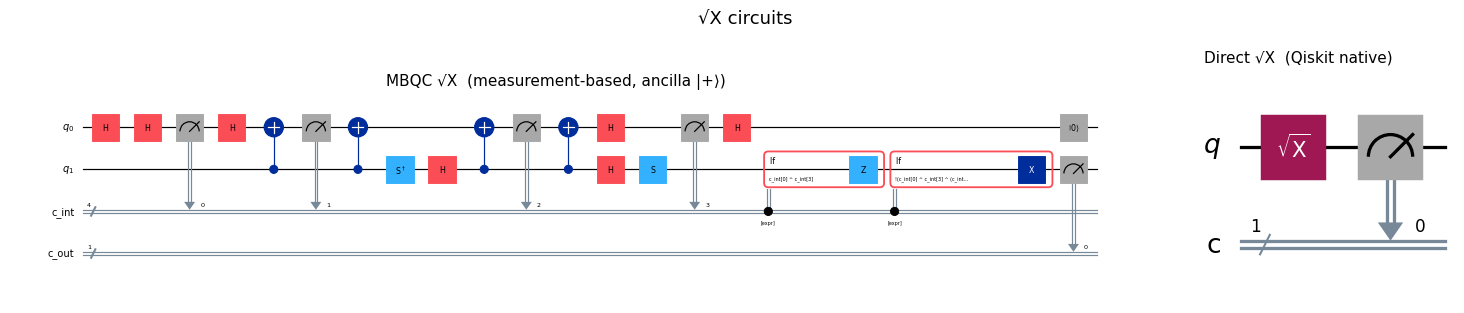

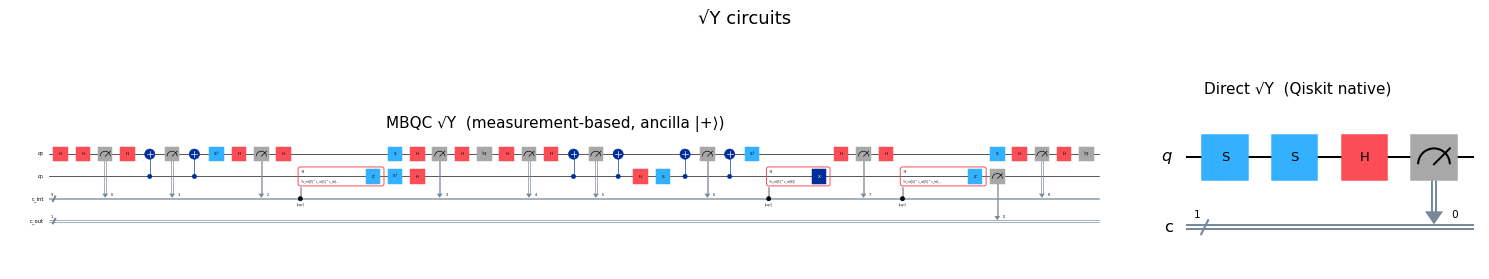

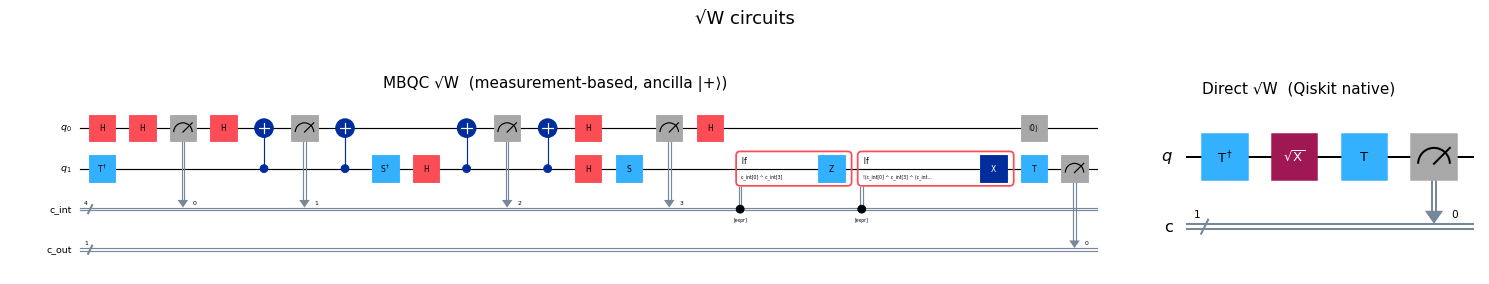

In [3]:
# Draw both circuits for each gate
for gate_name in ['sqrt_X', 'sqrt_Y', 'sqrt_W']:
    label     = LABELS[gate_name]
    mbqc_qc   = build_mbqc_circuit(gate_name)
    direct_qc = build_direct_circuit(gate_name)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 3),
                                      gridspec_kw={'width_ratios': [3, 1]})
    mbqc_qc.draw('mpl', fold=60, ax=ax_l)
    direct_qc.draw('mpl', ax=ax_r)
    ax_l.set_title(f'MBQC {label}  (measurement-based, ancilla |+\u27e9)', fontsize=11)
    ax_r.set_title(f'Direct {label}  (Qiskit native)', fontsize=11)
    plt.suptitle(f'{label} circuits', fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

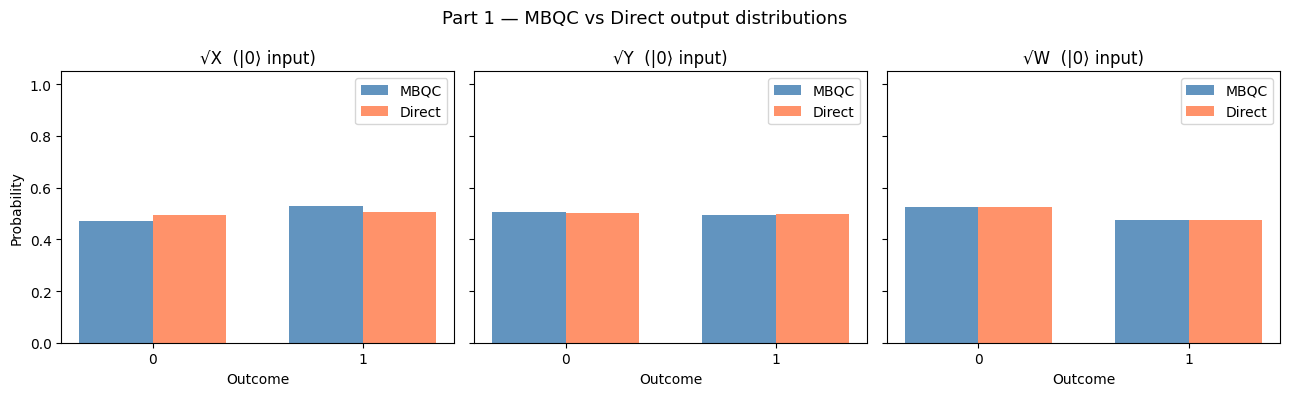

In [4]:
# Run from |0> and compare output distributions for all three gates
SHOTS    = 1024
gate_list = ['sqrt_X', 'sqrt_Y', 'sqrt_W']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, gate_name in zip(axes, gate_list):
    mbqc_counts, direct_counts = run_mbqc_direct(gate_name, init_state='0', shots=SHOTS)

    states   = ['0', '1']
    p_mbqc   = [mbqc_counts.get(s, 0)   / SHOTS for s in states]
    p_direct = [direct_counts.get(s, 0) / SHOTS for s in states]

    x, w = np.arange(2), 0.35
    ax.bar(x - w/2, p_mbqc,   w, label='MBQC',   color='steelblue', alpha=0.85)
    ax.bar(x + w/2, p_direct, w, label='Direct', color='coral',     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(states)
    ax.set_xlabel('Outcome'); ax.set_ylim(0, 1.05)
    ax.set_title(f'{LABELS[gate_name]}  (|0\u27e9 input)')
    ax.legend()

axes[0].set_ylabel('Probability')
plt.suptitle('Part 1 \u2014 MBQC vs Direct output distributions', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 2 — 12-pair random single-qubit RCS

**Qubit layout** (24 qubits total):
```
index:  0   1   2   3   4   5  ...  22  23
role:  d0  a0  d1  a1  d2  a2  ...  d11 a11
```
Each ancilla `a_i` is initialised to |+⟩.  
Each data qubit `d_i` gets a random gate from {√X, √Y, √W} applied via `a_i`.

In [5]:
np.random.seed(30)

N_PAIRS       = 12
BITS_PER_PAIR = 9                        # worst-case: sqrt_Y uses 9 intermediate bits
TOTAL_INT     = N_PAIRS * BITS_PER_PAIR  # 108 intermediate classical bits

random_gates = np.random.choice(['sqrt_X', 'sqrt_Y', 'sqrt_W'], size=N_PAIRS).tolist()

print('Gate assignment (seed=42):')
for i, g in enumerate(random_gates):
    print(f'  pair {i:2d}  data=q[{2*i:2d}]  ancilla=q[{2*i+1:2d}]  gate={LABELS[g]}')

# ── MBQC circuit: 24 qubits ──────────────────────────────────────────────────
qr      = QuantumRegister(N_PAIRS * 2, 'q')
c_int   = ClassicalRegister(TOTAL_INT, 'c_int')
c_data  = ClassicalRegister(N_PAIRS,   'c_data')
mbqc_qc = QuantumCircuit(qr, c_int, c_data)

for i, gate_name in enumerate(random_gates):
    data_q    = qr[i * 2]
    ancilla_q = qr[i * 2 + 1]
    mbqc_qc.h(ancilla_q)  # ancilla initialised to |+>
    GATE_FNS[gate_name](mbqc_qc, ancilla_q, data_q, c_int,
                        start_idx=i * BITS_PER_PAIR)

# Final readout: measure each data qubit into c_data
for i in range(N_PAIRS):
    mbqc_qc.measure(qr[i * 2], c_data[i])

# ── Direct circuit: 12 qubits ────────────────────────────────────────────────
qr_d      = QuantumRegister(N_PAIRS, 'q')
cr_d      = ClassicalRegister(N_PAIRS, 'c')
direct_qc = QuantumCircuit(qr_d, cr_d)

for i, gate_name in enumerate(random_gates):
    apply_direct_gate(direct_qc, gate_name, qr_d[i])

direct_qc.measure(qr_d, cr_d)

print(f'\nMBQC circuit :  {mbqc_qc.num_qubits} qubits, depth={mbqc_qc.depth()}')
print(f'Direct circuit: {direct_qc.num_qubits} qubits, depth={direct_qc.depth()}')

Gate assignment (seed=42):
  pair  0  data=q[ 0]  ancilla=q[ 1]  gate=√Y
  pair  1  data=q[ 2]  ancilla=q[ 3]  gate=√Y
  pair  2  data=q[ 4]  ancilla=q[ 5]  gate=√Y
  pair  3  data=q[ 6]  ancilla=q[ 7]  gate=√Y
  pair  4  data=q[ 8]  ancilla=q[ 9]  gate=√X
  pair  5  data=q[10]  ancilla=q[11]  gate=√X
  pair  6  data=q[12]  ancilla=q[13]  gate=√W
  pair  7  data=q[14]  ancilla=q[15]  gate=√Y
  pair  8  data=q[16]  ancilla=q[17]  gate=√Y
  pair  9  data=q[18]  ancilla=q[19]  gate=√W
  pair 10  data=q[20]  ancilla=q[21]  gate=√Y
  pair 11  data=q[22]  ancilla=q[23]  gate=√Y

MBQC circuit :  24 qubits, depth=36
Direct circuit: 12 qubits, depth=4


In [7]:
SHOTS2 = 1024
sim    = AerSimulator()

print('Running MBQC 24-qubit circuit ...')
mbqc_result = sim.run(
    transpile(mbqc_qc, sim, optimization_level=0), shots=SHOTS2
).result()

print('Running direct 12-qubit circuit ...')
direct_result = sim.run(
    transpile(direct_qc, sim), shots=SHOTS2
).result()

print('Done.')

mbqc_raw   = mbqc_result.get_counts()
direct_raw = direct_result.get_counts()

# MBQC bitstring: 'c_data c_int' (space-separated; c_data leftmost = last register added)
# Marginalise over c_int to keep only c_data
mbqc_data = defaultdict(int)
for bitstring, cnt in mbqc_raw.items():
    mbqc_data[bitstring.split(' ')[0]] += cnt

print(f'Unique MBQC data patterns : {len(mbqc_data)}')
print(f'Unique direct patterns    : {len(direct_raw)}')

Running MBQC 24-qubit circuit ...
Running direct 12-qubit circuit ...
Done.
Unique MBQC data patterns : 900
Unique direct patterns    : 895


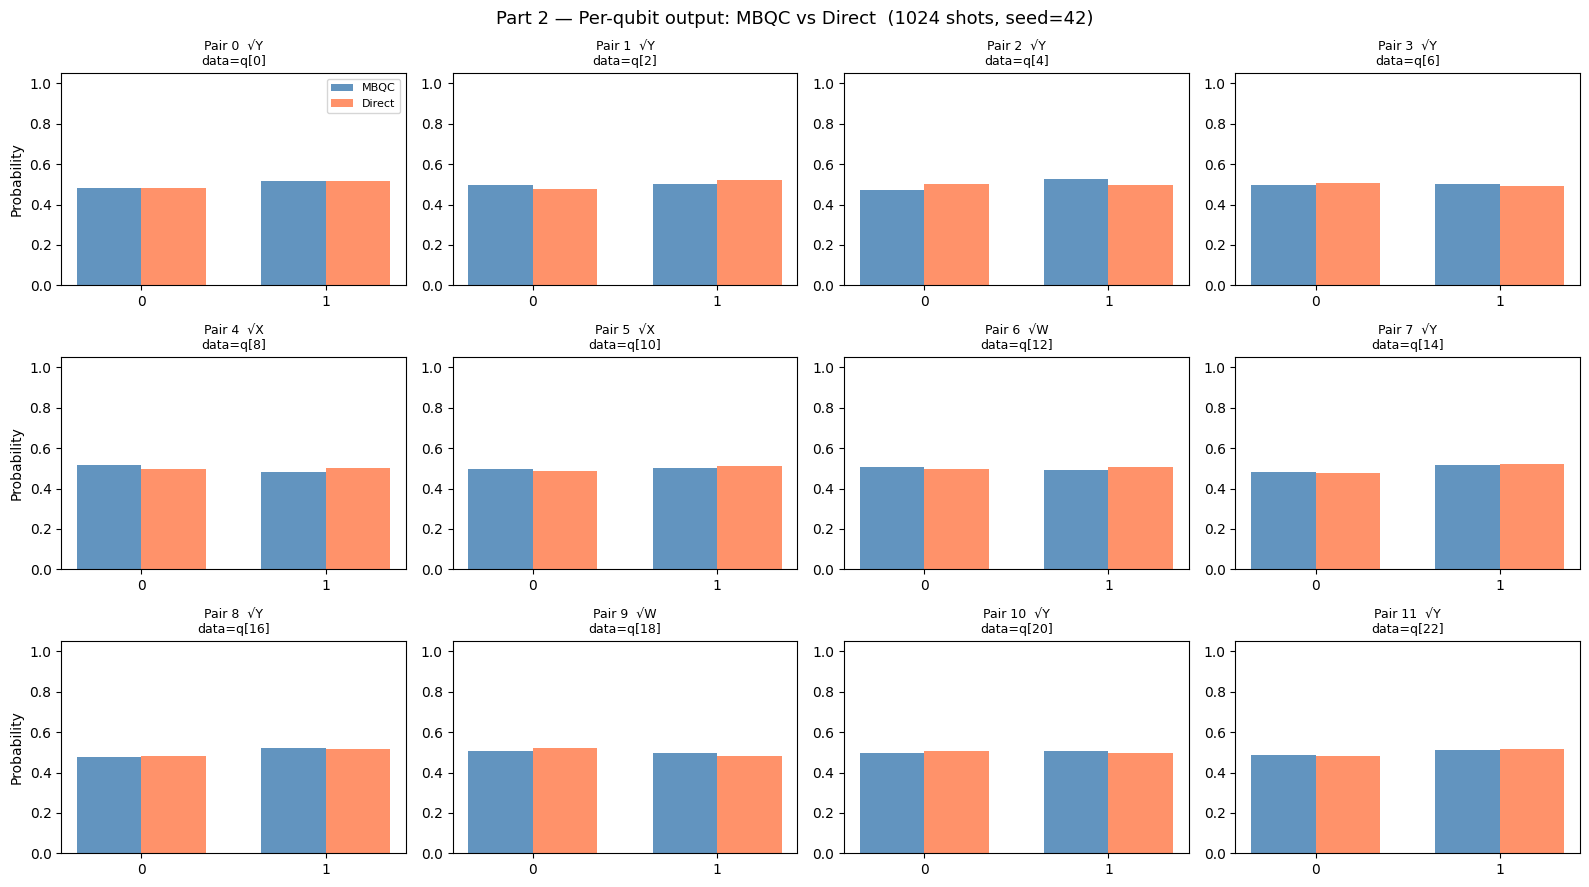

In [8]:
def qubit_marginal(counts, qubit_idx, n_bits):
    """Marginalise counts to a single qubit.
    Qiskit bitstrings: MSB (highest index) is leftmost char.
    Bit at qubit_idx sits at char position n_bits-1-qubit_idx.
    """
    pos = n_bits - 1 - qubit_idx
    out = defaultdict(int)
    for bits, cnt in counts.items():
        out[bits[pos]] += cnt
    return dict(out)


fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes_flat = axes.flatten()

for i in range(N_PAIRS):
    label_g = LABELS[random_gates[i]]
    m_marg  = qubit_marginal(dict(mbqc_data), i, N_PAIRS)
    d_marg  = qubit_marginal(direct_raw,      i, N_PAIRS)

    states = ['0', '1']
    p_m    = [m_marg.get(s, 0) / SHOTS2 for s in states]
    p_d    = [d_marg.get(s, 0) / SHOTS2 for s in states]

    ax = axes_flat[i]
    x, w = np.arange(2), 0.35
    ax.bar(x - w/2, p_m, w, label='MBQC',   color='steelblue', alpha=0.85)
    ax.bar(x + w/2, p_d, w, label='Direct', color='coral',     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(states)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Pair {i}  {label_g}\ndata=q[{2*i}]', fontsize=9)
    if i % 4 == 0:
        ax.set_ylabel('Probability')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    f'Part 2 \u2014 Per-qubit output: MBQC vs Direct  ({SHOTS2} shots, seed=42)',
    fontsize=13
)
plt.tight_layout()
plt.show()

In [10]:
# Total Variation Distance per qubit — should be ~0 within shot noise
print('Total Variation Distance per qubit (MBQC vs Direct):')
print(f'{"Pair":<6} {"Gate":<5} {"TVD":>8}')
print('-' * 22)

tvds = []
for i in range(N_PAIRS):
    m_marg = qubit_marginal(dict(mbqc_data), i, N_PAIRS)
    d_marg = qubit_marginal(direct_raw,      i, N_PAIRS)
    keys   = set(m_marg) | set(d_marg)
    tvd    = 0.5 * sum(abs(m_marg.get(k, 0)/SHOTS2 - d_marg.get(k, 0)/SHOTS2) for k in keys)
    tvds.append(tvd)
    print(f'{i:<6} {LABELS[random_gates[i]]:<5} {tvd:>8.4f}')

print('-' * 22)
print(f'{"Mean TVD:":<11} {np.mean(tvds):.4f}')
print(f'{"Max  TVD:":<11} {np.max(tvds):.4f}')
print('\nTVD \u2248 0 confirms MBQC and direct circuits agree within shot noise.')

Total Variation Distance per qubit (MBQC vs Direct):
Pair   Gate       TVD
----------------------
0      √Y      0.0020
1      √Y      0.0176
2      √Y      0.0303
3      √Y      0.0088
4      √X      0.0195
5      √X      0.0107
6      √W      0.0137
7      √Y      0.0029
8      √Y      0.0078
9      √W      0.0156
10     √Y      0.0098
11     √Y      0.0059
----------------------
Mean TVD:   0.0120
Max  TVD:   0.0303

TVD ≈ 0 confirms MBQC and direct circuits agree within shot noise.
